# Step 16: Hybrid Intelligence Gatekeeper

## 🎯 Objective:
Memperbaiki performa AI Gatekeeper dengan cara menggabungkan fitur-fitur makro, mikro, dan topologi.

## 💡 Fix Applied:
Memperbaiki kalkulasi **Graph Density** agar tidak menggunakan `.apply()` pada rolling window, melainkan menggunakan iterasi yang stabil untuk mendapatkan kepadatan jaringan global pasar crypto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ Hybrid Environment Ready!")

✅ Hybrid Environment Ready!


## 1. Feature Engineering (The Hybrid Matrix)

In [2]:
# Load Data
df = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = df.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0)
crypto_assets = [c for c in df.columns if c != 'PAXG-USD']
crypto_rets = returns[crypto_assets]

# A. PCA Features
scaler = StandardScaler()
pca = PCA(n_components=5)
pca_factors = pca.fit_transform(scaler.fit_transform(crypto_rets))
X_hybrid = pd.DataFrame(pca_factors, index=crypto_rets.index, columns=[f'PC{i+1}' for i in range(5)])

# B. Volatility Features
X_hybrid['BTC_Vol_20'] = crypto_rets['BTC-USD'].rolling(20).std()
X_hybrid['BTC_Vol_60'] = crypto_rets['BTC-USD'].rolling(60).std()
X_hybrid['Vol_Ratio'] = X_hybrid['BTC_Vol_20'] / X_hybrid['BTC_Vol_60']

# C. Graph Density Features (Stable Implementation)
def calculate_graph_density_series(ret_df, window=20, threshold=0.5):
    print("🔄 Calculating rolling graph density (Stable Version)...")
    rolling_corr = ret_df.rolling(window).corr()
    densities = []
    dates = []
    v = len(ret_df.columns)
    max_edges = v * (v - 1) / 2
    
    # Iterasi per tanggal yang valid
    valid_dates = ret_df.index[window-1:]
    for date in valid_dates:
        corr_matrix = rolling_corr.loc[date].fillna(0)
        adj_matrix = (corr_matrix > threshold).astype(int)
        edges = (adj_matrix.values.sum() - v) / 2
        densities.append(edges / max_edges if max_edges > 0 else 0)
        dates.append(date)
    return pd.Series(densities, index=dates)

X_hybrid['Graph_Density'] = calculate_graph_density_series(crypto_rets)

# D. Target (0.5% shift -1)
y_val = np.where(crypto_rets['BTC-USD'].shift(-1) > 0.005, 1, 0)
X_hybrid['Target'] = y_val
X_hybrid = X_hybrid.dropna()

print(f"✅ Hybrid Feature Matrix Created. Shape: {X_hybrid.shape}")

🔄 Calculating rolling graph density (Stable Version)...
✅ Hybrid Feature Matrix Created. Shape: (931, 10)


## 2. Hybrid Model Training

In [3]:
train_period = X_hybrid.index.year < 2025
test_period = X_hybrid.index.year == 2025

X_train = X_hybrid[train_period].drop(columns=['Target'])
y_train = X_hybrid[train_period]['Target']
X_test = X_hybrid[test_period].drop(columns=['Target'])
y_test = X_hybrid[test_period]['Target']

hybrid_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

hybrid_model.fit(X_train, y_train)

y_pred = hybrid_model.predict(X_test)
print(f"🏆 Hybrid AI Accuracy (2025): {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

🏆 Hybrid AI Accuracy (2025): 59.18%

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.79      0.71       232
           1       0.40      0.25      0.31       133

    accuracy                           0.59       365
   macro avg       0.52      0.52      0.51       365
weighted avg       0.56      0.59      0.56       365



## 3. Backtest: The Redemption

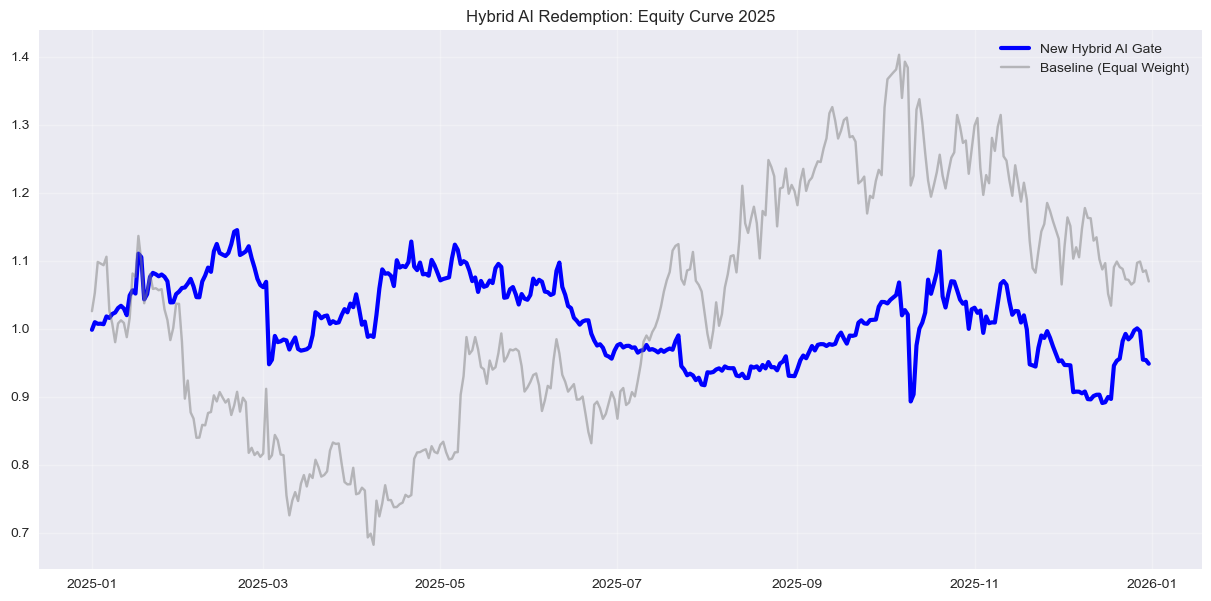

--- BACKTEST SUMMARY ---
                      Total Return (%)  Sharpe Ratio  Max Drawdown (%)
Hybrid_AI_Gate               -5.147979      0.011078        -22.207801
Baseline_EqualWeight          6.954710      0.335156        -39.963529


In [4]:
results = pd.DataFrame(index=X_test.index)
paxg_ret_test = returns.loc[X_test.index, 'PAXG-USD']
baseline_ret = (returns.loc[X_test.index, crypto_assets]).mean(axis=1) 

# AI Prediction Signal (0 = Bearish/Risk-Off, 1 = Bullish/Risk-On)
results['Hybrid_AI_Gate'] = np.where(y_pred == 1, baseline_ret, paxg_ret_test)
results['Baseline_EqualWeight'] = baseline_ret

cumulative = (1 + results).cumprod()
plt.figure(figsize=(15, 7))
plt.plot(cumulative['Hybrid_AI_Gate'], label='New Hybrid AI Gate', lw=3, color='blue')
plt.plot(cumulative['Baseline_EqualWeight'], label='Baseline (Equal Weight)', alpha=0.5, color='gray')
plt.title('Hybrid AI Redemption: Equity Curve 2025')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

summary = pd.DataFrame({
    'Total Return (%)': (cumulative.iloc[-1] - 1) * 100,
    'Sharpe Ratio': results.mean() / results.std() * np.sqrt(252),
    'Max Drawdown (%)': (cumulative / cumulative.cummax() - 1).min() * 100
})
print("--- BACKTEST SUMMARY ---")
print(summary)

## ✅ Feature Importance

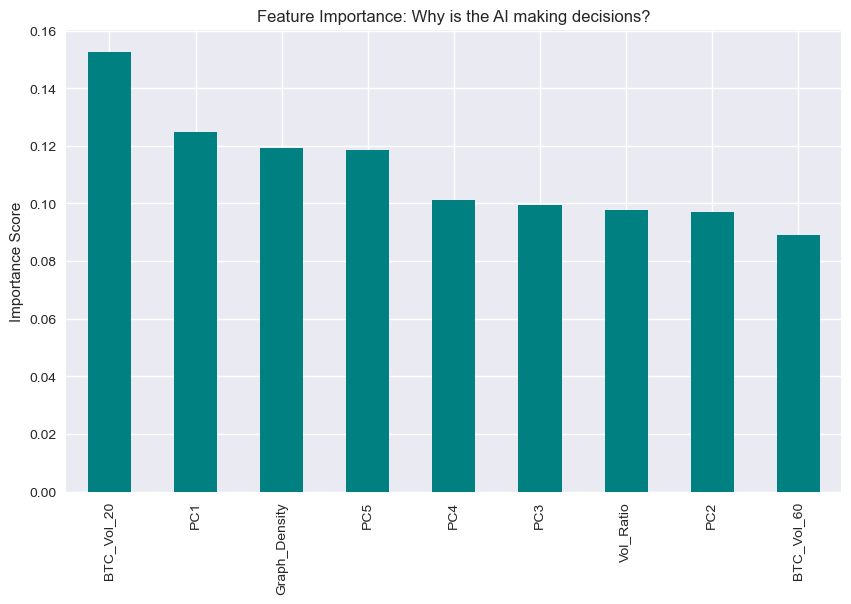

In [5]:
feat_imp = pd.Series(hybrid_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='teal')
plt.title('Feature Importance: Why is the AI making decisions?')
plt.ylabel('Importance Score')
plt.show()